# Évaluation Single-Task Online — TinyOL (Dataset 2 — Equipment Monitoring)

| Paramètre | Valeur |
|-----------|--------|
| **Modèle** | TinyOL (`MonitoringAutoencoder 4→8→4` + `OtOHead`) |
| **Dataset** | Equipment Monitoring (Dataset 2) — tous équipements fusionnés |
| **Scénario** | Single-task, apprentissage **online** (un échantillon à la fois) |
| **Évaluation** | Prequential (predict-then-update) + contribution des variables |
| **Expérience** | `exp_032_tinyol_monitoring_single_task` |
| **Sprint** | S11 |

**Architecture adaptée** : Le backbone original TinyOL a `input_dim=25` (features windowed pump dataset).  
Pour le dataset monitoring (4 features tabulaires), on utilise un autoencoder minimal `4→8→4`  
compatible avec `TinyOLOnlineTrainer` (même interface `forward(x) → (z, x_hat)`).

**Section 0** : Pretraining du backbone sur les échantillons normaux (faulty=0) du train split.  
Fraction de préentraînement : 30% des données normales.

## Section 0 — Définition et pretraining du backbone (4→8→4)

In [1]:
# Section 1 — Setup & imports
import json
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, roc_auc_score, roc_curve

from src.data.monitoring_dataset import get_monitoring_dataloaders_single_task
from src.evaluation.feature_importance import (
    permutation_importance,
    plot_feature_importance,
)
from src.models.tinyol.oto_head import OtOHead, TinyOLOnlineTrainer
from IPython.display import display, Image

MODEL_NAME    = "TinyOL"
EXP_DIR       = REPO_ROOT / "experiments" / "exp_032_tinyol_monitoring_single_task"
FIGURES_DIR   = REPO_ROOT / "notebooks" / "figures" / "cl_evaluation" / "tinyol" / "monitoring" / "single_task"
CSV_PATH      = REPO_ROOT / "data" / "raw" / "equipment_monitoring" / "Industrial_Equipment_Monitoring_Dataset" / "equipment_anomaly_data.csv"
FEATURE_NAMES = ["temperature", "pressure", "vibration", "humidity"]
SEED          = 42
PRETRAIN_FRAC = 0.30   # fraction d'échantillons normaux pour préentraînement backbone

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Repo root : {REPO_ROOT}")
print(f"CSV exists: {CSV_PATH.exists()}")

Repo root : /home/leonard/Documents/ENAC/cl-embedded
CSV exists: True


In [2]:
class MonitoringAutoencoder(nn.Module):
    """
    Autoencoder minimal 4→8→4 pour Equipment Monitoring.

    Interface identique à TinyOLAutoencoder :
    - forward(x: [batch, 4]) → (z: [batch, 8], x_hat: [batch, 4])
    - Compatible avec TinyOLOnlineTrainer

    Paramètres : enc(4→8)=40 + dec(8→4)=36 = 76 params → 304 B @ FP32
    """

    def __init__(self) -> None:
        super().__init__()
        self.enc = nn.Linear(4, 8)   # MEM: 40 params → 160 B @ FP32 / 40 B @ INT8
        self.dec = nn.Linear(8, 4)   # MEM: 36 params → 144 B @ FP32 / 36 B @ INT8

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z     = self.enc(x)     # [batch, 8] — pas de ReLU au goulot (encodage linéaire)
        x_hat = self.dec(z)     # [batch, 4]
        return z, x_hat

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.enc(x)      # [batch, 8]


backbone = MonitoringAutoencoder()
n_backbone = sum(p.numel() for p in backbone.parameters())
print(f"Backbone params : {n_backbone} (enc={sum(p.numel() for p in backbone.enc.parameters())} + dec={sum(p.numel() for p in backbone.dec.parameters())})")  # attend : 76
print(f"OtOHead input_dim = 8 (latent) + 1 (MSE) = 9")

Backbone params : 76 (enc=40 + dec=36)
OtOHead input_dim = 8 (latent) + 1 (MSE) = 9


## Section 2 — Métriques batch pré-calculées (exp_032)

In [3]:
metrics_path = EXP_DIR / "results" / "metrics_single_task.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        batch_metrics = json.load(f)
    print("Métriques exp_032 :")
    for k, v in batch_metrics.items():
        print(f"  {k:30s}: {v}")
else:
    print(f"[WARN] {metrics_path} introuvable")
    batch_metrics = {}

Métriques exp_032 :
  exp_id                        : exp_032_tinyol_monitoring_single_task
  accuracy                      : 0.9446254071661238
  f1                            : 0.6255506607929515
  auc_roc                       : 0.838010650473407
  ram_peak_bytes                : 944
  inference_latency_ms          : 0.008875780076778028
  n_params                      : 90


## Section 3 — Résumé visuel des métriques

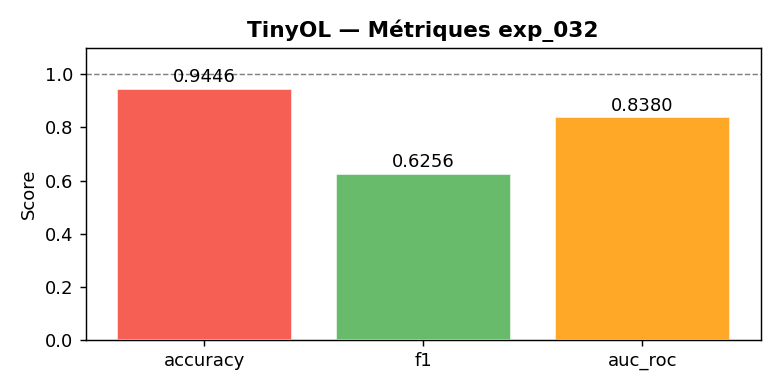

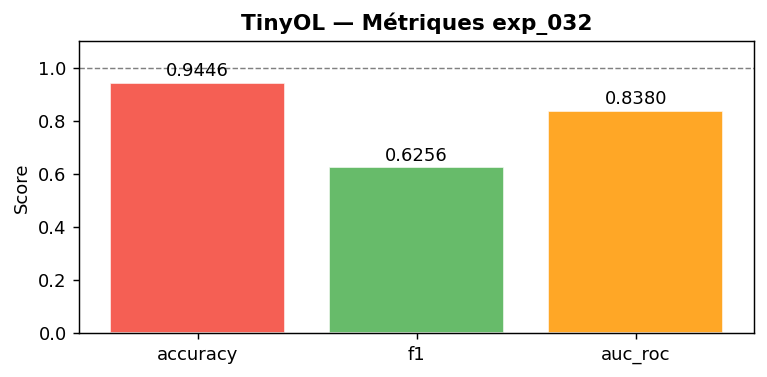

In [4]:
if batch_metrics:
    fig, ax = plt.subplots(figsize=(6, 3), dpi=130)
    metric_keys = ["accuracy", "f1", "auc_roc"]
    vals = [batch_metrics.get(k, 0) for k in metric_keys]
    bars = ax.bar(metric_keys, vals, color=["#F44336", "#4CAF50", "#FF9800"], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{MODEL_NAME} — Métriques exp_032", fontweight="bold")
    ax.set_ylabel("Score")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "batch_metrics.png", dpi=130)
    display(Image(str(FIGURES_DIR / "batch_metrics.png")))

## Section 4 — Chargement des données + pretraining backbone

In [5]:
assert CSV_PATH.exists(), f"CSV introuvable : {CSV_PATH}"

data = get_monitoring_dataloaders_single_task(
    csv_path=CSV_PATH,
    batch_size=1,
    test_ratio=0.2,
    val_ratio=0.1,
    seed=SEED,
)

def loader_to_numpy(loader):
    Xs, ys = [], []
    for x_batch, y_batch in loader:
        Xs.append(x_batch.numpy())
        ys.append(y_batch.numpy())
    return np.concatenate(Xs).squeeze(), np.concatenate(ys).squeeze()

X_train, y_train = loader_to_numpy(data["train_loader"])
X_test,  y_test  = loader_to_numpy(data["test_loader"])

print(f"Train : {X_train.shape}, faulty={y_train.mean():.3f}")
print(f"Test  : {X_test.shape},  faulty={y_test.mean():.3f}")

✅ Seed fixé à 42
Train : (5523, 4), faulty=0.100
Test  : (1535, 4),  faulty=0.100


Données normales disponibles  : 4970
Échantillons de préentraîn.   : 1491 (30% des normaux)


/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



Pretraining terminé — Loss finale : 0.000000


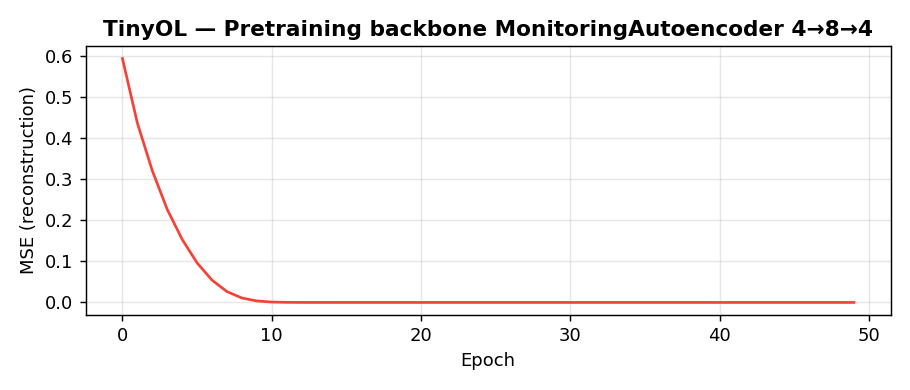

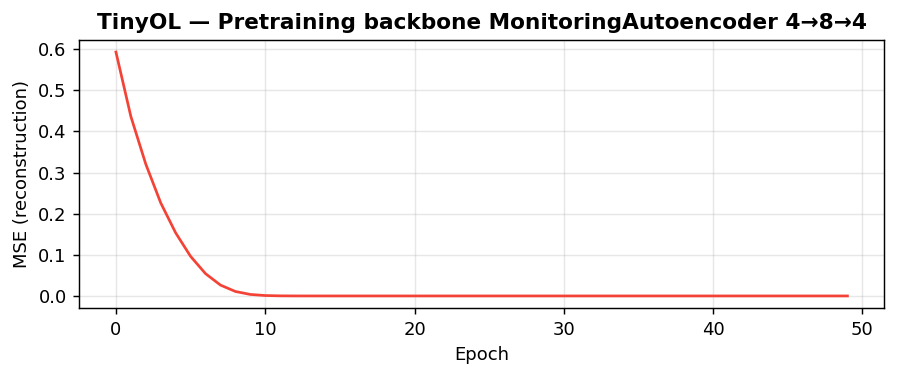

In [6]:
# Pretraining backbone sur échantillons normaux (faulty=0) du train split
# Protocole TinyOL : préentraîner l'encodeur sur données normales uniquement (MSE reconstruction)

X_normal = X_train[y_train == 0].astype(np.float32)

# Fraction de préentraînement (30%)
n_pretrain = int(len(X_normal) * PRETRAIN_FRAC)
rng = np.random.default_rng(SEED)
pretrain_idx = rng.choice(len(X_normal), size=n_pretrain, replace=False)
X_pretrain = X_normal[pretrain_idx]

print(f"Données normales disponibles  : {len(X_normal)}")
print(f"Échantillons de préentraîn.   : {n_pretrain} ({PRETRAIN_FRAC:.0%} des normaux)")

# Boucle de préentraînement (MSE, Adam, 50 epochs)
pretrain_optim = torch.optim.Adam(backbone.parameters(), lr=1e-3)
X_pretrain_t = torch.from_numpy(X_pretrain)

PRETRAIN_EPOCHS = 50
PRETRAIN_BATCH  = 32
pretrain_losses = []

backbone.train()
for epoch in range(PRETRAIN_EPOCHS):
    perm = torch.randperm(len(X_pretrain_t))
    epoch_loss = 0.0
    n_batches  = 0
    for i in range(0, len(X_pretrain_t), PRETRAIN_BATCH):
        batch = X_pretrain_t[perm[i:i + PRETRAIN_BATCH]]
        _, x_hat = backbone(batch)
        loss = F.mse_loss(x_hat, batch)
        pretrain_optim.zero_grad()
        loss.backward()
        pretrain_optim.step()
        epoch_loss += loss.item()
        n_batches  += 1
    pretrain_losses.append(epoch_loss / max(n_batches, 1))

print(f"\nPretraining terminé — Loss finale : {pretrain_losses[-1]:.6f}")

# Courbe de préentraînement
fig, ax = plt.subplots(figsize=(7, 3), dpi=130)
ax.plot(pretrain_losses, color="#F44336", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (reconstruction)")
ax.set_title("TinyOL — Pretraining backbone MonitoringAutoencoder 4→8→4", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pretrain_loss.png", dpi=130)
display(Image(str(FIGURES_DIR / "pretrain_loss.png")))

## Section 5 — Boucle online prequential (predict-then-update)

Le backbone est gelé après pretraining. Seule la tête OtO (`Linear(9→1)`) est mise à jour.  
La boucle prequential : predict → record → update, un échantillon à la fois.

In [7]:
# Initialisation du trainer TinyOL
oto_head = OtOHead(input_dim=9)  # 8D latent + 1D MSE
config_oto = {"oto_head": {"learning_rate": 0.01, "momentum": 0.0}}
trainer = TinyOLOnlineTrainer(backbone, oto_head, config_oto)

n_oto_params = oto_head.n_params()
print(f"OtO head params    : {n_oto_params}")
print(f"Backbone gelé      : {not any(p.requires_grad for p in backbone.parameters())}")

all_probs:  list[float] = []
all_labels: list[int]   = []
all_losses: list[float] = []

for xi, yi in zip(X_train, y_train):
    x_t = torch.from_numpy(xi.astype(np.float32))  # [4]
    y_t = torch.tensor(float(yi))

    # 1. Prédiction AVANT la mise à jour
    prob, _ = trainer.predict(x_t)
    all_probs.append(prob)
    all_labels.append(int(yi))

    # 2. Mise à jour SGD sur ce seul échantillon
    loss_val = trainer.update(x_t, y_t)
    all_losses.append(loss_val)

prequential_acc = float(np.mean((np.array(all_probs) >= 0.5) == np.array(all_labels)))
print(f"\nAccuracy prequential (train stream) : {prequential_acc:.4f}")
print(f"Loss BCE moyenne                     : {np.mean(all_losses):.4f}")

OtO head params    : 10
Backbone gelé      : True

Accuracy prequential (train stream) : 0.9297
Loss BCE moyenne                     : 0.2679


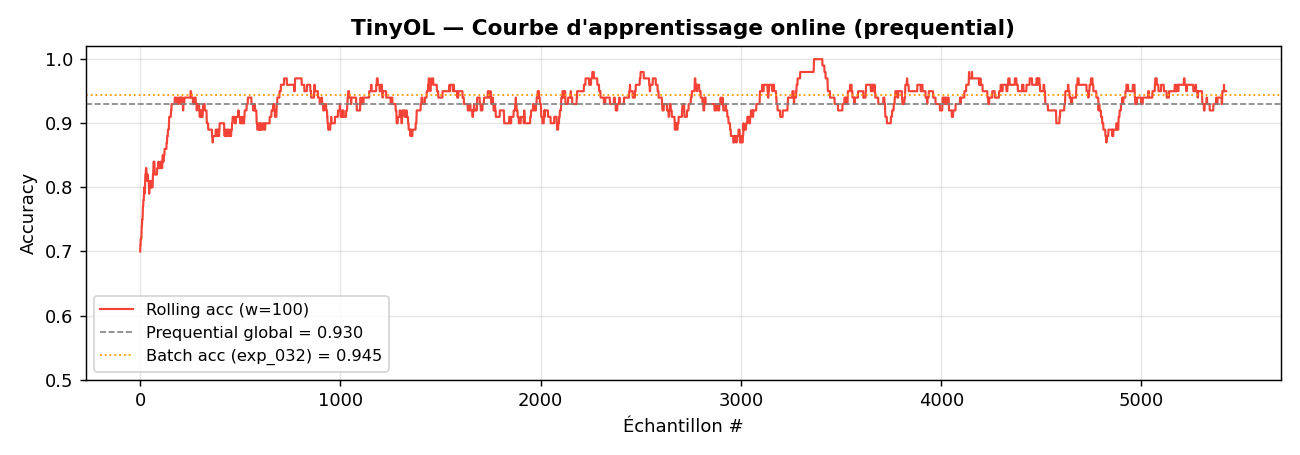

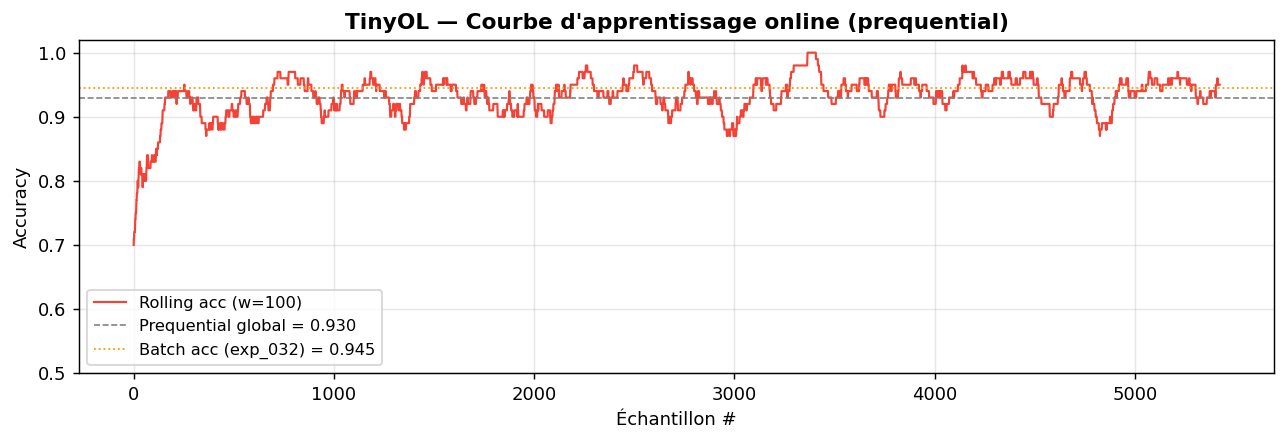

In [8]:
WINDOW = 100
preds_bin  = (np.array(all_probs) >= 0.5).astype(int)
labels_arr = np.array(all_labels)
rolling_acc = np.convolve((preds_bin == labels_arr).astype(float),
                           np.ones(WINDOW) / WINDOW, mode="valid")

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=130)
ax.plot(rolling_acc, color="#F44336", linewidth=1.2, label=f"Rolling acc (w={WINDOW})")
ax.axhline(prequential_acc, color="gray", linestyle="--", linewidth=0.9,
           label=f"Prequential global = {prequential_acc:.3f}")
if batch_metrics.get("accuracy"):
    ax.axhline(batch_metrics["accuracy"], color="#FF9800", linestyle=":", linewidth=1,
               label=f"Batch acc (exp_032) = {batch_metrics['accuracy']:.3f}")
ax.set_xlabel("Échantillon #")
ax.set_ylabel("Accuracy")
ax.set_title(f"{MODEL_NAME} — Courbe d'apprentissage online (prequential)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "prequential_rolling_acc.png", dpi=130)
display(Image(str(FIGURES_DIR / "prequential_rolling_acc.png")))

## Section 6 — Évaluation finale sur le test set

In [9]:
test_probs  = np.array([trainer.predict(torch.from_numpy(xi.astype(np.float32)))[0]
                         for xi in X_test])
THRESHOLD   = 0.5
test_preds  = (test_probs >= THRESHOLD).astype(int)
test_acc    = float(np.mean(test_preds == y_test.astype(int)))
test_auc    = roc_auc_score(y_test.astype(int), test_probs)
test_f1     = f1_score(y_test.astype(int), test_preds, zero_division=0)

print(f"Test accuracy : {test_acc:.4f}")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print(f"Test F1       : {test_f1:.4f}")

Test accuracy : 0.9433
Test AUC-ROC  : 0.7810
Test F1       : 0.6063


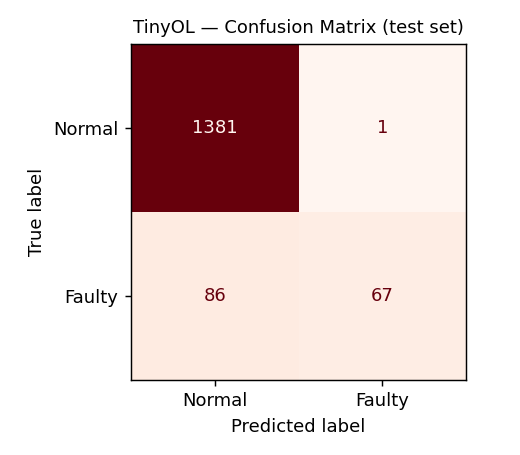

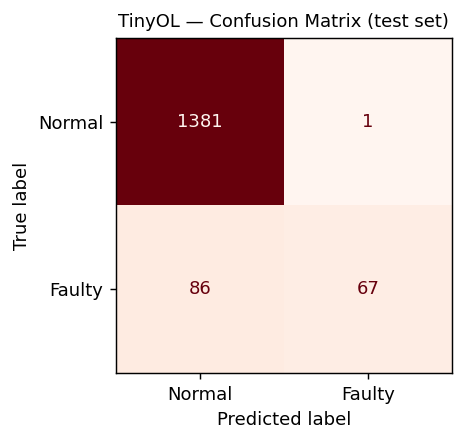

In [10]:
cm = confusion_matrix(y_test.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=130)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Faulty"]).plot(ax=ax, colorbar=False, cmap="Reds")
ax.set_title(f"{MODEL_NAME} — Confusion Matrix (test set)", fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=130)
display(Image(str(FIGURES_DIR / "confusion_matrix.png")))

## Section 7 — Courbe ROC

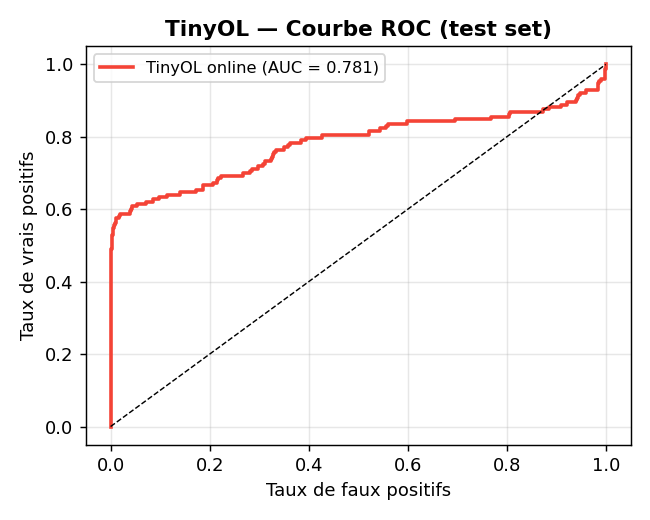

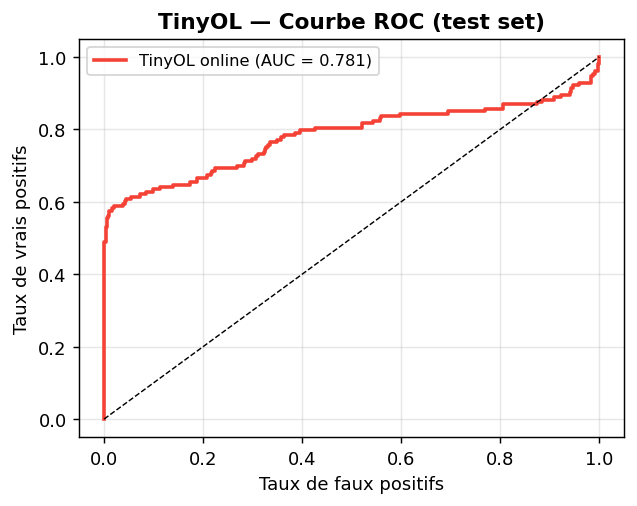

In [11]:
fpr, tpr, _ = roc_curve(y_test.astype(int), test_probs)

fig, ax = plt.subplots(figsize=(5, 4), dpi=130)
ax.plot(fpr, tpr, color="#F44336", linewidth=2, label=f"TinyOL online (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title(f"{MODEL_NAME} — Courbe ROC (test set)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curve.png", dpi=130)
display(Image(str(FIGURES_DIR / "roc_curve.png")))

## Section 8 — Espace des features (PCA 2D)

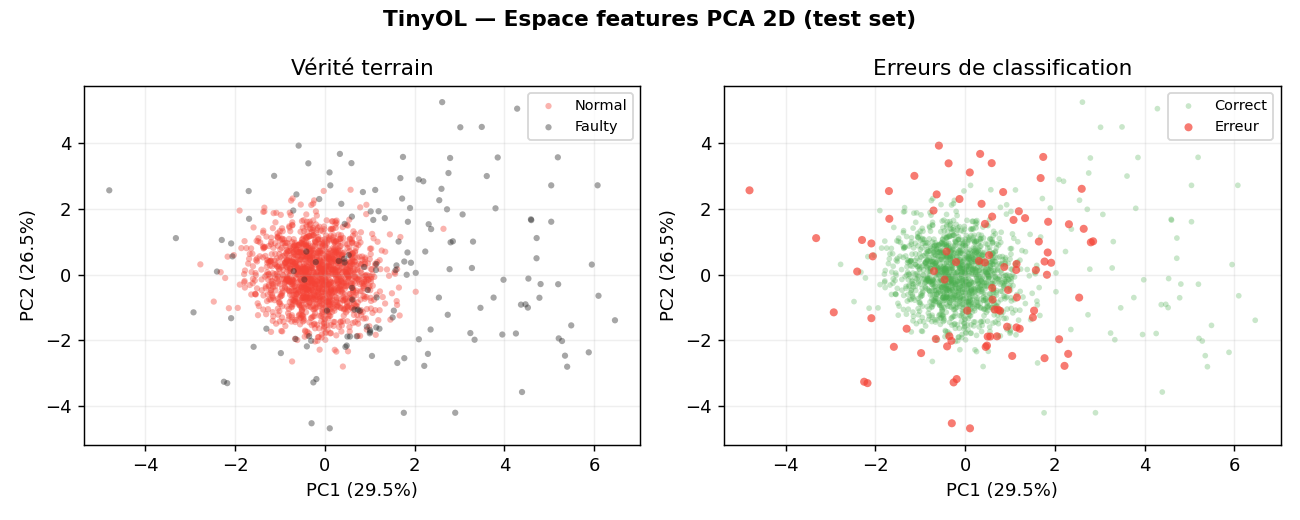

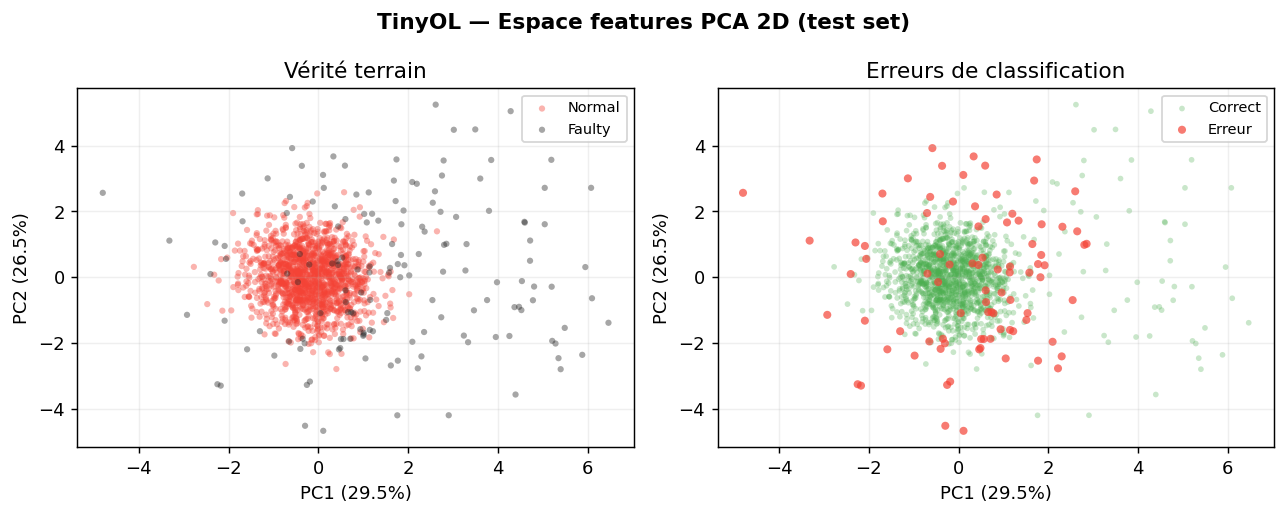

In [12]:
pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=130)

for label, name, c in [(0, "Normal", "#F44336"), (1, "Faulty", "#212121")]:
    mask = y_test.astype(int) == label
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], c=c, alpha=0.4, s=12, label=name, edgecolors="none")
axes[0].set_title("Vérité terrain")
axes[0].legend(fontsize=8)

correct = (test_preds == y_test.astype(int))
axes[1].scatter(X_test_2d[correct, 0],  X_test_2d[correct, 1],  c="#4CAF50", alpha=0.3, s=10, label="Correct",   edgecolors="none")
axes[1].scatter(X_test_2d[~correct, 0], X_test_2d[~correct, 1], c="#F44336", alpha=0.7, s=20, label="Erreur",    edgecolors="none")
axes[1].set_title("Erreurs de classification")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.2)

fig.suptitle(f"{MODEL_NAME} — Espace features PCA 2D (test set)", fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_feature_space.png", dpi=130)
display(Image(str(FIGURES_DIR / "pca_feature_space.png")))

## Section 9 — Tableau récapitulatif

In [13]:
n_params_total = n_backbone + n_oto_params
# RAM : backbone 76 params × 4 B + OtO 10 params × 4 B = 344 B
ram_est = n_params_total * 4

print("=" * 55)
print(f"  Modèle           : {MODEL_NAME} (backbone 4→8→4 + OtO)")
print("-" * 55)
print(f"  Backbone params  : {n_backbone}")
print(f"  OtO head params  : {n_oto_params}")
print(f"  Total params     : {n_params_total}")
print(f"  RAM estimée      : {ram_est} B ({ram_est/1024:.2f} Ko)")
print(f"  Latence inférence: {batch_metrics.get('inference_latency_ms', 'N/A')} ms")
print("-" * 55)
print(f"  Acc. exp_032 (batch) : {batch_metrics.get('accuracy', 'N/A'):.4f}")
print(f"  Acc. prequential     : {prequential_acc:.4f}")
print(f"  Acc. test (online)   : {test_acc:.4f}")
print(f"  AUC-ROC (test)       : {test_auc:.4f}")
print(f"  F1 (test)            : {test_f1:.4f}")
print("-" * 55)
budget_ok = ram_est <= 65536
print(f"  Budget RAM 64 Ko : {'✅ OK' if budget_ok else '❌ DÉPASSÉ'} ({ram_est/1024:.2f} Ko / 64 Ko)")
print("=" * 55)

  Modèle           : TinyOL (backbone 4→8→4 + OtO)
-------------------------------------------------------
  Backbone params  : 76
  OtO head params  : 10
  Total params     : 86
  RAM estimée      : 344 B (0.34 Ko)
  Latence inférence: 0.008875780076778028 ms
-------------------------------------------------------
  Acc. exp_032 (batch) : 0.9446
  Acc. prequential     : 0.9297
  Acc. test (online)   : 0.9433
  AUC-ROC (test)       : 0.7810
  F1 (test)            : 0.6063
-------------------------------------------------------
  Budget RAM 64 Ko : ✅ OK (0.34 Ko / 64 Ko)


## Section 10 — Contribution individuelle des variables

La permutation importance opère dans l'**espace d'entrée brut** (4 features Z-score normalisées).  
Elle mesure l'impact de chaque variable originale sur la prédiction finale (à travers l'encodeur gelé + OtO head).

Note : l'encodeur étant linéaire (4→8), la permutation d'une feature perturbe
directement les 8 dimensions du vecteur latent — l'interprétation est directe.

In [14]:
# predict_fn pour TinyOL — opère dans l'espace d'entrée 4D
def tinyol_predict_fn(X_np: np.ndarray) -> np.ndarray:
    probs = []
    for xi in X_np:
        x_t = torch.from_numpy(xi.astype(np.float32))
        prob, _ = trainer.predict(x_t)
        probs.append(prob)
    return np.array(probs)

print("Calcul permutation importance (n_repeats=10)...")
perm_imp = permutation_importance(
    predict_fn=tinyol_predict_fn,
    X=X_test,
    y=y_test,
    feature_names=FEATURE_NAMES,
    n_repeats=10,
    random_state=SEED,
    threshold=THRESHOLD,
)

print("\nPermutation Importance :")
for feat, score in perm_imp.items():
    print(f"  {feat:15s}: {score:+.4f}")

Calcul permutation importance (n_repeats=10)...

Permutation Importance :
  vibration      : +0.0661
  temperature    : +0.0046
  pressure       : +0.0029
  humidity       : +0.0007


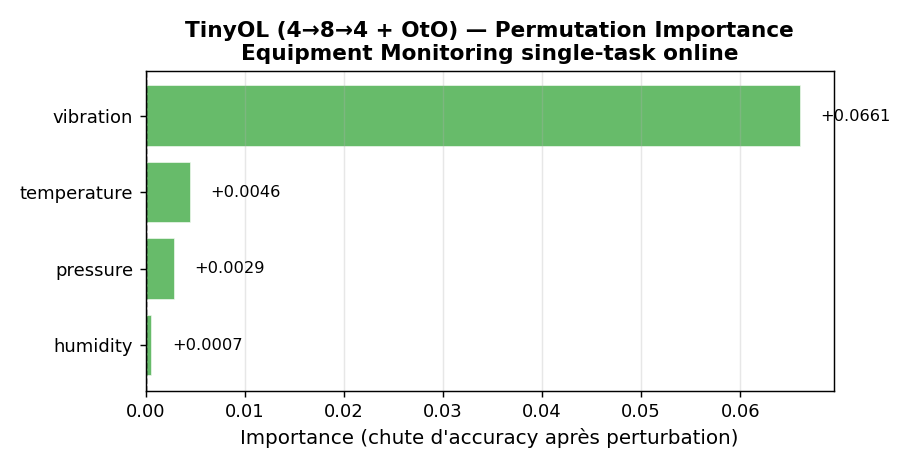

Variable la plus importante : vibration (score=+0.0661)


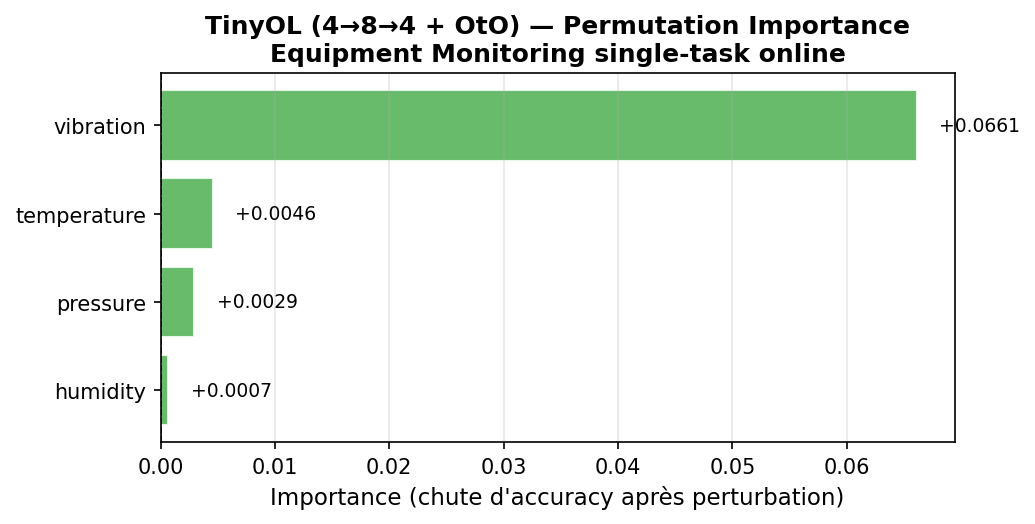

In [15]:
fig = plot_feature_importance(
    perm_imp,
    title=f"{MODEL_NAME} (4→8→4 + OtO) — Permutation Importance\nEquipment Monitoring single-task online",
    color="#F44336",
)
fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=130)
display(Image(str(FIGURES_DIR / "feature_importance.png")))

top_feat = max(perm_imp, key=perm_imp.get)
print(f"Variable la plus importante : {top_feat} (score={perm_imp[top_feat]:+.4f})")

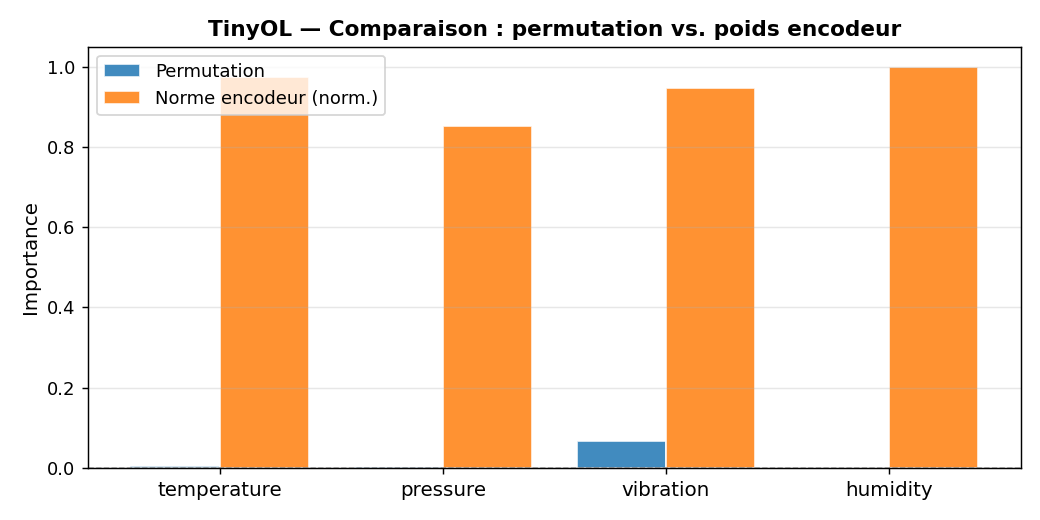

Normes L2 des colonnes de l'encodeur (contribution brute par feature) :
  humidity       : 1.3146
  temperature    : 1.2810
  vibration      : 1.2452
  pressure       : 1.1201


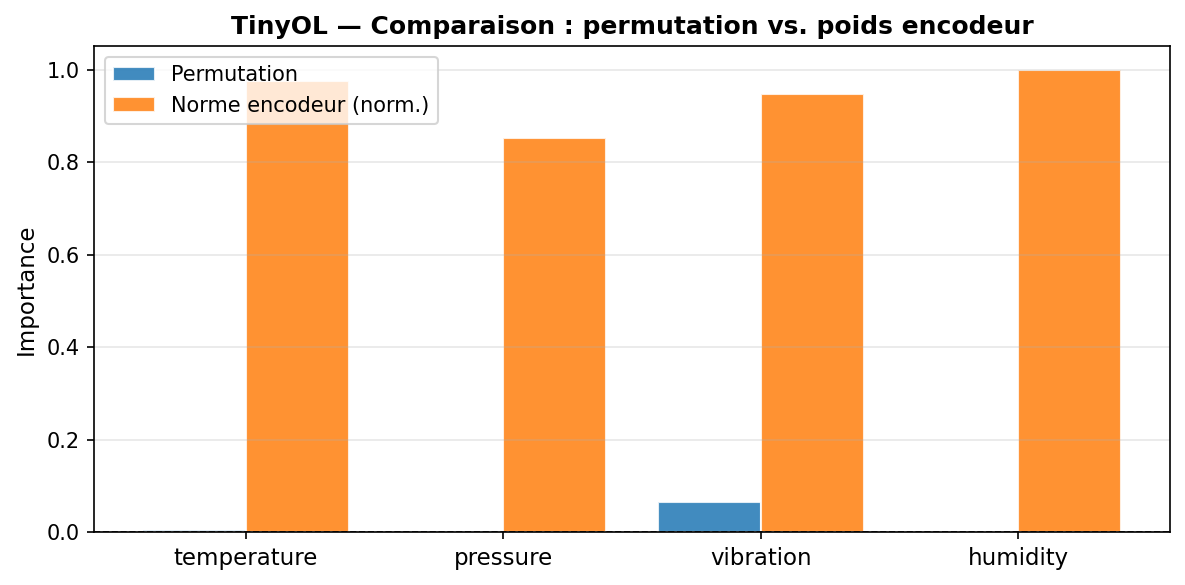

In [16]:
# Analyse supplémentaire : poids de l'encodeur (contribution linéaire de chaque feature)
# W_enc[j, :] = poids de la feature j vers les 8 neurones latents
W_enc = backbone.enc.weight.detach().numpy()  # [8, 4]
feat_norm_enc = np.linalg.norm(W_enc, axis=0)  # norme L2 de chaque colonne = contribution feature j

enc_importance = {FEATURE_NAMES[j]: float(feat_norm_enc[j]) for j in range(4)}
enc_importance = dict(sorted(enc_importance.items(), key=lambda kv: kv[1], reverse=True))

from src.evaluation.feature_importance import plot_feature_importance_comparison

# Normaliser les normes d'encodeur pour comparer à la permutation
max_norm = max(enc_importance.values())
enc_norm_scaled = {k: v / max_norm for k, v in enc_importance.items()}

fig = plot_feature_importance_comparison(
    {"Permutation": perm_imp, "Norme encodeur (norm.)": enc_norm_scaled},
    feature_names=FEATURE_NAMES,
    title=f"{MODEL_NAME} — Comparaison : permutation vs. poids encodeur",
)
fig.savefig(FIGURES_DIR / "feature_importance_comparison.png", dpi=130)
display(Image(str(FIGURES_DIR / "feature_importance_comparison.png")))

print("Normes L2 des colonnes de l'encodeur (contribution brute par feature) :")
for feat, val in enc_importance.items():
    print(f"  {feat:15s}: {val:.4f}")

In [17]:
importance_results = {
    "model": MODEL_NAME,
    "backbone_architecture": "4→8→4 (MonitoringAutoencoder)",
    "dataset": "equipment_monitoring",
    "scenario": "single_task_online",
    "n_params_backbone": n_backbone,
    "n_params_oto": n_oto_params,
    "test_accuracy": test_acc,
    "test_auc_roc": test_auc,
    "prequential_accuracy": prequential_acc,
    "permutation_importance": perm_imp,
    "encoder_weight_norms": enc_importance,
}

out_path = EXP_DIR / "results" / "feature_importance.json"
with open(out_path, "w") as f:
    json.dump(importance_results, f, indent=2)

print(f"Résultats sauvegardés : {out_path}")
print("\n✅ Notebook TinyOL single-task online — terminé.")

Résultats sauvegardés : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_032_tinyol_monitoring_single_task/results/feature_importance.json

✅ Notebook TinyOL single-task online — terminé.
